In [10]:
# !pip uninstall -y flax orbax-checkpoint jax jaxlib \
#     ml-dtypes tf-keras tensorflow tensorflow-cpu tensorflow-text \
#     tensorflow-decision-forests keras keras-hub \
#     chex optax fastai spacy tensorstore numba \
#     umap-learn pynndescent librosa shap cuml-cu12 cudf-cu12 dask-cuda

%pip install -U threadpoolctl joblib
#%pip install --force-reinstall numpy==1.26.4
%pip install --upgrade scikit-learn
%pip install -U imbalanced-learn umap-learn

%pip install --upgrade --force-reinstall \
    numpy \
    scipy \
    matplotlib \
    seaborn \
    pandas \
    tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 7.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 10.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (60 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.2.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached tensorflow-2.19.0-cp39-cp39-macosx_12_0_arm64.whl.metadata (4.0 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycl

In [3]:
import importlib, random, os, numpy as np, tensorflow as tf

print("===== VERSIONS =====")
for lib in ("numpy", "pandas", "sklearn", "imblearn",
            "tensorflow", "matplotlib", "seaborn"):
    m = importlib.import_module(lib if lib != "sklearn" else "sklearn")
    print(f"{lib:17s}: {m.__version__}")

print("\n===== TensorFlow devices =====")
print(tf.config.list_physical_devices())   # ← здесь будет только CPU, и это нормально

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"\nRandom seed set to {SEED}")

===== VERSIONS =====
numpy            : 1.24.3
pandas           : 2.0.3
sklearn          : 1.3.2
imblearn         : 0.12.4
tensorflow       : 2.13.0
matplotlib       : 3.7.5
seaborn          : 0.13.2

===== TensorFlow devices =====
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Random seed set to 42


In [7]:
# === @title Этап 2 (Kaggle API) — Ethereum Fraud Detection ===
# 0. (если делали раньше, шаги с pip и токеном можно пропустить)

# — 0.1 Установка библиотеки kaggle —
%pip install --quiet kaggle

# # — 0.2 Загрузка kaggle.json (один раз за сессию Colab) —
# #    Если токен уже лежит в ~/.kaggle, эту строку можно пропустить.
# from google.colab import files, auth
# import pathlib, io, os, json, pandas as pd

# if not pathlib.Path("~/.kaggle/kaggle.json").expanduser().exists():
#     print("📂 Загрузите kaggle.json ➜")
#     token_file = files.upload()           # откроется диалог
#     if "kaggle.json" not in token_file:
#         raise ValueError("Нужно загрузить файл под именем kaggle.json")
#     pathlib.Path("~/.kaggle").expanduser().mkdir(exist_ok=True)
#     with open(pathlib.Path("~/.kaggle/kaggle.json").expanduser(), "wb") as f:
#         f.write(token_file["kaggle.json"])
#     !chmod 600 ~/.kaggle/kaggle.json
# else:
#     print("🔑 kaggle.json уже настроен")

import os
import json
import pathlib
import pandas as pd
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

# 1. Убедимся, что у нас есть файл kaggle.json (с токеном Kaggle)
kaggle_json_path = '../kaggle.json'

if not os.path.exists(kaggle_json_path):
    raise FileNotFoundError("Файл 'kaggle.json' не найден. Пожалуйста, скачайте его с вашего аккаунта Kaggle.")

# 2. Конфигурируем API Kaggle с использованием токена
with open(kaggle_json_path) as f:
    kaggle_json = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_json['username']
os.environ['KAGGLE_KEY'] = kaggle_json['key']

# 3. Инициализируем API
api = KaggleApi()
api.authenticate()

# 1. Скачиваем архив датасета
slug = "vagifa/ethereum-frauddetection-dataset"
print(f"\n⬇️ Скачиваю датасет {slug} ...")
!kaggle datasets download -d {slug} -p ./data --force --quiet

# 2. Распаковываем
print("📦 Распаковываю ...")
!unzip -o ./data/*.zip -d ./data > /dev/null

# 3. Открываем transactions.csv
csv_path = "./data/transactions.csv"
if not os.path.exists(csv_path):
    # fallback: берем первый найденный CSV
    import glob
    found = glob.glob("./data/**/*.csv", recursive=True)
    if not found:
        raise RuntimeError("CSV-файлы не найдены в архиве.")
    csv_path = found[0]
print(f"✅ Нашёл CSV: {csv_path}")

df = pd.read_csv(csv_path)

# 4. Отладочная информация
print("\n===== SHAPE =====")
print(df.shape)            # ожидаем (9840, 49)

print("\n===== HEAD (5 строк) =====")
display(df.head())

print("\n===== Классовое соотношение (isFraud) =====")
if "FLAG" in df.columns:
    display((df["FLAG"].value_counts(normalize=True) * 100).round(2).rename("%"))
else:
    print("Столбец 'FLAG' не найден — проверьте структуру датасета.")

Note: you may need to restart the kernel to use updated packages.

⬇️ Скачиваю датасет vagifa/ethereum-frauddetection-dataset ...
Dataset URL: https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset
License(s): DbCL-1.0
  0%|                                                | 0.00/923k [00:00<?, ?B/s]
100%|████████████████████████████████████████| 923k/923k [00:00<00:00, 1.88GB/s]
📦 Распаковываю ...
✅ Нашёл CSV: ./data/transaction_dataset.csv

===== SHAPE =====
(9841, 51)

===== HEAD (5 строк) =====


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS



===== Классовое соотношение (isFraud) =====


FLAG
0    77.86
1    22.14
Name: %, dtype: float64

In [1]:
import pandas as pd
df = pd.read_csv('../dataset/data2/lstm_dataset_address.csv')

# 4. Отладочная информация
print("\n===== SHAPE =====")
print(df.shape)

print("\n===== HEAD (5 строк) =====")
display(df.head())

print("\n===== Классовое соотношение (isFraud) =====")
if "FLAG" in df.columns:
    display((df["FLAG"].value_counts(normalize=True) * 100).round(2).rename("%"))
else:
    print("Столбец 'FLAG' не найден — проверьте структуру датасета.")


===== SHAPE =====
(36875, 49)

===== HEAD (5 строк) =====


,address,FLAG,FLAG_NUM,is_contract,scam_type,Sent_tnx,Number_of_Created_Contracts,Unique_Sent_To_Addresses,Min_Val_Sent,Max_Val_Sent,...,ERC20_Avg_Val_Rec,ERC20_Min_Val_Sent,ERC20_Max_Val_Sent,ERC20_Avg_Val_Sent,ERC20_Min_Val_Sent_Contract,ERC20_Max_Val_Sent_Contract,ERC20_Uniq_Sent_Token_Name,ERC20_Uniq_Rec_Token_Name,ERC20_Most_Sent_Token_Type,ERC20_Most_Rec_Token_Type
0,0x4a2b1e35eb64141bbad4c58cb7d79692bc5dbbc2,legit,0,False,NaN,19.0,0.0,5.0,0.000010,1.609000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0xef16b2733d4fd4090824af46c8153af0b43722d2,legit,0,False,phish,17.0,0.0,2.0,0.099748,1.009811,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0x04914e7f178a1f3717d5afabfc2103255bcc0a5f,scam,1,False,NaN,12.0,0.0,8.0,0.000000,0.012892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0x9fa2bc6baf2139fc470ed935b7550d81345224c2,legit,0,False,NaN,120.0,0.0,2.0,0.118875,3.120779,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0xc2d02ddedba39a0e2c06fc3ab5241de5e1893513,legit,0,False,NaN,32.0,0.0,1.0,0.527314,2.253756,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== Классовое соотношение (isFraud) =====


FLAG
legit      78.99
scam       20.52
suspect     0.49
Name: %, dtype: float64

In [2]:
import pandas as pd

# Загрузка датасета
df = pd.read_csv('../dataset/data2/lstm_dataset_address.csv')

df['FLAG'] = df['FLAG'].map({'scam': 1, 'legit': 0})
df = df[df['is_contract']==False]

print(df.shape)


(16121, 49)


In [3]:
df.drop(columns=["Unnamed: 0", "Index", "FLAG_NUM", "is_contract", "scam_type"], inplace=True, errors="ignore")
df['FLAG'].value_counts(normalize=True)

FLAG
0.0    0.581658
1.0    0.418342
Name: proportion, dtype: float64

==> Shape после удаления служебных колонок: (16121, 46)

===== ТОП-10 столбцов по числу NaN =====


ERC20_Most_Sent_Token_Type         13431
ERC20_Most_Rec_Token_Type          11271
Min_Value_Sent_To_Contract          9985
Max_Value_Sent_To_Contract          9985
Avg_Value_Sent_To_Contract          9985
ERC20_Max_Val_Rec                   8688
ERC20_Uniq_Sent_Addr                8688
ERC20_Uniq_Rec_Addr                 8688
ERC20_Uniq_Rec_Contract_Addr        8688
ERC20_Avg_Time_Between_Sent_Tnx     8688
dtype: int64

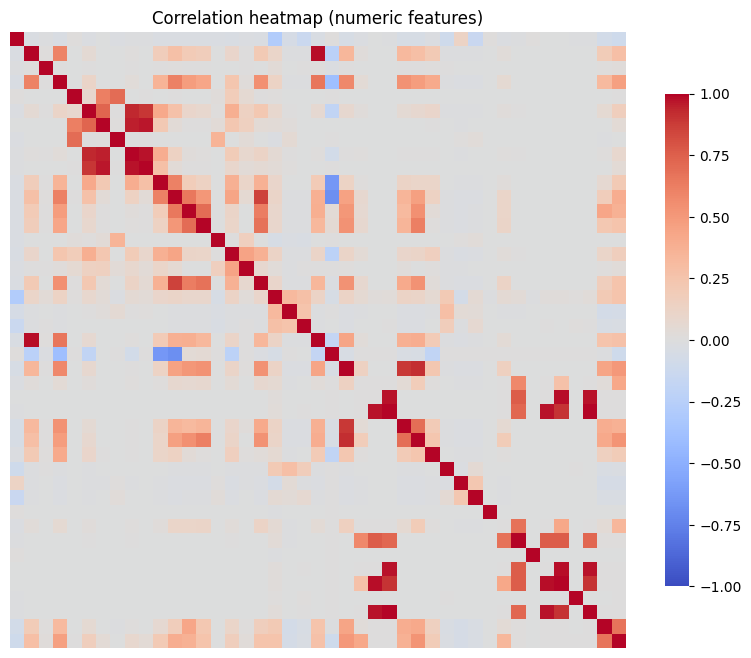


===== Признаки с нулевой дисперсией (n=0) =====
[]

===== Распределение FLAG =====


FLAG
0.0    58.17
1.0    41.83
Name: %, dtype: float64

In [4]:
# === @title Этап 3: первичный анализ и инвентаризация признаков ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# 0) Копируем исходный df (на всякий случай)
df_eda = df.copy()

# 1) Удаляем служебные колонки, если есть
svc_cols = ["Unnamed: 0", "Index"]
df_eda.drop(columns=[c for c in svc_cols if c in df_eda.columns],
            inplace=True, errors="ignore")

print("==> Shape после удаления служебных колонок:", df_eda.shape)

# 2) Проверяем пропуски
na_counts = df_eda.isna().sum()
na_nonzero = na_counts[na_counts > 0].sort_values(ascending=False)

print("\n===== ТОП-10 столбцов по числу NaN =====")
display(na_nonzero.head(10))

# 3) Корреляционная матрица Пирсона
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[num_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0,
            vmax=1, vmin=-1, square=True,
            cbar_kws={"shrink": .8}, xticklabels=False, yticklabels=False)
plt.title("Correlation heatmap (numeric features)")
plt.show()

# 4) Признаки с нулевой дисперсией (постоянные значения)
zero_var = df_eda[num_cols].loc[:, df_eda[num_cols].nunique() == 1].columns.tolist()
print(f"\n===== Признаки с нулевой дисперсией (n={len(zero_var)}) =====")
print(zero_var)

# 5) Быстрый взгляд на распределение классов (FLAG)
print("\n===== Распределение FLAG =====")
display(df_eda["FLAG"].value_counts(normalize=True).rename("%").mul(100).round(2))

In [5]:
# import pandas as pd

# # Группы по классу
# df_flag_1 = df[df['FLAG'] == 1]
# df_flag_0 = df[df['FLAG'] == 0]

# # Определим минимальное количество между классами
# min_class_count = min(len(df_flag_1), len(df_flag_0))

# # Случайная выборка из каждого класса
# df_flag_1_sampled = df_flag_1.sample(n=min_class_count, random_state=42)
# df_flag_0_sampled = df_flag_0.sample(n=int(min_class_count), random_state=42)

# # Объединяем и перемешиваем
# df_balanced = pd.concat([df_flag_1_sampled, df_flag_0_sampled], ignore_index=True)
# df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# # Проверим баланс классов
# print(df_balanced['FLAG'].value_counts())

# # Обновляем переменную df
# df = df_balanced


In [6]:
# === @title Этап 4: очистка признаков перед обучением ===

import pandas as pd, numpy as np

# 0) Копируем исходный df
df_clean = df.copy()

# 1) Убираем пробелы в заголовках и служебные поля
df_clean.columns = df_clean.columns.str.strip()
df_clean.drop(columns=["Unnamed: 0", "Index"], inplace=True, errors="ignore")

# 2) Удаляем все строковые столбцы (Address, токены и т.п.)
str_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
print("Удаляю строковые колонки:", str_cols)
df_clean = df_clean.drop(columns=str_cols)

# 3) Удаляем признаки с нулевой дисперсией
to_drop = [c for c in zero_var if c in df_clean.columns]
print("Удаляю zero-variance:", to_drop)
df_clean = df_clean.drop(columns=to_drop)

# 4) Заполняем все NaN медианой по столбцу
num_cols = df_clean.columns.tolist()  # теперь все — числовые
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 5) Убираем одну из пары сильнокоррелирующих признаков (|ρ| > 0.9)
corr = df_clean.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Удаляю сильно коррелирующие (>0.9):", high_corr_drop)
df_clean = df_clean.drop(columns=high_corr_drop)

# 6) Финальная проверка
print("\nИтоговая форма df_clean:", df_clean.shape)
print("Осталось NaN всего:", df_clean.isna().sum().sum())

Удаляю строковые колонки: ['address', 'ERC20_Most_Sent_Token_Type', 'ERC20_Most_Rec_Token_Type']
Удаляю zero-variance: []
Удаляю сильно коррелирующие (>0.9): ['Max_Value_Sent_To_Contract', 'Avg_Value_Sent_To_Contract', 'Total_Transactions_Including_Tnx_to_Create_Contract', 'ERC20_Total_Ether_Sent_Contract', 'ERC20_Uniq_Rec_Addr', 'ERC20_Max_Val_Sent', 'ERC20_Avg_Val_Sent', 'ERC20_Max_Val_Sent_Contract']

Итоговая форма df_clean: (16121, 35)
Осталось NaN всего: 0


In [7]:
# === @title Этап 5: разделение и SMOTE ===
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler


# 1) Готовим X и y
SEED = 42
X = df_clean.drop(columns=["FLAG"])
y = df_clean["FLAG"]

# 1) Разбиваем на train+val и test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2) Делим оставшиеся на train и val (75/25 от X_temp → в итоге 60/20/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,    # 0.25 * 0.8 = 0.2
    stratify=y_temp,
    random_state=42
)

# 3) SMOTE только на train
sm = SMOTE(random_state=42)
X_train_res, y_train_res = X_train, y_train

# 4) Масштабирование только по train_res
scaler = MinMaxScaler()
scaler.fit(X_train_res)

X_train_s = scaler.transform(X_train_res)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# 5) reshape для LSTM
n_features    = X_train_s.shape[1]
X_train_lstm  = X_train_s.reshape(-1, 1, n_features)
X_val_lstm    = X_val_s.reshape(-1,   1, n_features)
X_test_lstm   = X_test_s.reshape(-1,  1, n_features)

# 6) Правильно формируем y-объекты для валидации и теста
y_val_lstm  = y_val.to_numpy()   # или y_val.values
y_test_lstm = y_test.to_numpy()  # или y_test.values


In [8]:
# import pandas as pd
# from imblearn.over_sampling import SMOTE
# from sklearn.decomposition import PCA
# import umap
# import matplotlib.pyplot as plt

# # 1. Получаем X_train_res, y_train_res
# sm = SMOTE(random_state=42)
# X_res, y_res = sm.fit_resample(X_train, y_train)

# # 2. Помечаем, какие точки синтетические
# is_synth = ['real'] * len(X_train) + ['synthetic'] * (len(X_res) - len(X_train))
# df_vis = pd.DataFrame(X_res)
# df_vis['label'] = y_res
# df_vis['type']  = is_synth
# import numpy as np

# X_raw = df_vis.drop(columns=['label','type'])
# cols_inf = [c for c in X_raw.columns if np.isinf(X_raw[c]).any()]
# print("Есть inf в столбцах:", cols_inf)
# X_clean = X_raw.replace([np.inf, -np.inf], np.nan)
# X_clean = X_clean.fillna(X_clean.median())

# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(X_clean)


# # 3. UMAP в 2D
# reducer = umap.UMAP(n_components=2, random_state=42)
# emb = reducer.fit_transform(X_scaled)

# # 4. Рисуем
# plt.figure(figsize=(8,6))
# for t, m in [('real','o'), ('synthetic','x')]:
#     idx = df_vis['type']==t
#     plt.scatter(emb[idx,0], emb[idx,1],
#                 c=df_vis.loc[idx,'label'], marker=m,
#                 alpha=0.6, label=t)
# plt.legend()
# plt.title("UMAP: реальные vs синтетические точки")
# plt.show()


In [9]:
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# # X_res — массив всех точек после SMOTE, y_res — их метки
# # mask_synth — булев массив, где True для синтетических
# X_array = X_res  # shape (n_res, n_features)
# y_array = y_res  # shape (n_res,)
# mask_synth = np.array(is_synth) == 'synthetic'

# # Найдём k ближайших соседей по Евклиду
# k = 10
# nn = NearestNeighbors(n_neighbors=k+1).fit(X_array)
# distances, indices = nn.kneighbors(X_array)

# bad = []  # здесь будем собирать %
# for i in np.where(mask_synth)[0]:
#     neigh_idx = indices[i][1:]  # без себя самого
#     # сколько среди соседей — другого класса?
#     frac_other = np.mean(y_array[neigh_idx] != y_array[i])
#     bad.append(frac_other)

# # Посмотрим распределение
# import matplotlib.pyplot as plt
# plt.hist(bad, bins=20)
# plt.xlabel("Доля соседей другого класса")
# plt.ylabel("Число синтетических точек")
# plt.title("Насколько «грязная» синтетика?")
# plt.show()

# # Сколько точек с frac_other > 0.5
# print("Сомнительных точек (>50% чужих соседей):",
#       np.sum(np.array(bad)>0.5), "из", len(bad))


In [10]:
# === @title Этап 8: построение LSTM-модели ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1) Создаём модель
model = Sequential([
    LSTM(64, input_shape=(1, X_train_lstm.shape[2])),  # timesteps=1, features=n_features
    Dense(1, activation='sigmoid')
])

# 2) Компиляция
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3) Вывод структуры модели
model.summary()

/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        25,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,409 (99.25 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200

Epoch 1: val_loss improved from inf to 0.63241, saving model to checkpoints/lstm_best_weights.h5


303/303 - 1s - 4ms/step - accuracy: 0.5936 - loss: 0.7731 - val_accuracy: 0.5853 - val_loss: 0.6324 - learning_rate: 1.0000e-03
Epoch 2/200

Epoch 2: val_loss improved from 0.63241 to 0.61620, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 1ms/step - accuracy: 0.6029 - loss: 0.7241 - val_accuracy: 0.6154 - val_loss: 0.6162 - learning_rate: 1.0000e-03
Epoch 3/200

Epoch 3: val_loss did not improve from 0.61620
303/303 - 0s - 955us/step - accuracy: 0.6128 - loss: 0.7151 - val_accuracy: 0.6045 - val_loss: 0.6202 - learning_rate: 1.0000e-03
Epoch 4/200

Epoch 4: val_loss improved from 0.61620 to 0.61548, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 976us/step - accuracy: 0.6197 - loss: 0.7108 - val_accuracy: 0.6222 - val_loss: 0.6155 - learning_rate: 1.0000e-03
Epoch 5/200

Epoch 5: val_loss improved from 0.61548 to 0.61477, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 971us/step - accuracy: 0.6262 - loss: 0.7066 - val_accuracy: 0.6222 - val_loss: 0.6148 - learning_rate: 1.0000e-03
Epoch 6/200

Epoch 6: val_loss did not improve from 0.61477
303/303 - 0s - 973us/step - accuracy: 0.6328 - loss: 0.7031 - val_accuracy: 0.6200 - val_loss: 0.6155 - learning_rate: 1.0000e-03
Epoch 7/200

Epoch 7: val_loss did not improve from 0.61477
303/303 - 0s - 996us/step - accuracy: 0.6352 - loss: 0.7008 - val_accuracy: 0.6160 - val_loss: 0.6174 - learning_rate: 1.0000e-03
Epoch 8/200

Epoch 8: val_loss improved from 0.61477 to 0.61063, saving model to checkpoints/lstm_best_weights.h5


...

303/303 - 0s - 982us/step - accuracy: 0.6886 - loss: 0.6659 - val_accuracy: 0.6749 - val_loss: 0.5983 - learning_rate: 2.5000e-04
Epoch 32/200

Epoch 32: val_loss did not improve from 0.59833
303/303 - 0s - 995us/step - accuracy: 0.6912 - loss: 0.6655 - val_accuracy: 0.6659 - val_loss: 0.6015 - learning_rate: 2.5000e-04
Epoch 33/200

Epoch 33: val_loss improved from 0.59833 to 0.59711, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 971us/step - accuracy: 0.6904 - loss: 0.6648 - val_accuracy: 0.6759 - val_loss: 0.5971 - learning_rate: 2.5000e-04
Epoch 34/200

Epoch 34: val_loss did not improve from 0.59711
303/303 - 0s - 965us/step - accuracy: 0.6917 - loss: 0.6644 - val_accuracy: 0.6638 - val_loss: 0.6027 - learning_rate: 2.5000e-04
Epoch 35/200

Epoch 35: val_loss did not improve from 0.59711
303/303 - 0s - 959us/step - accuracy: 0.6909 - loss: 0.6640 - val_accuracy: 0.6650 - val_loss: 0.6012 - learning_rate: 2.5000e-04
Epoch 36/200

Epoch 36: val_loss did not improve from 0.59711
303/303 - 0s - 994us/step - accuracy: 0.6912 - loss: 0.6633 - val_accuracy: 0.6600 - val_loss: 0.6048 - learning_rate: 2.5000e-04
Epoch 37/200

Epoch 37: val_loss did not improve from 0.59711
303/303 - 0s - 999us/step - accuracy: 0.6918 - loss: 0.6629 - val_accuracy: 0.6613 - val_loss: 0.6041 - learning_rate: 2.5000e-04
Epoch 38/200

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 38: 

303/303 - 0s - 997us/step - accuracy: 0.6907 - loss: 0.6608 - val_accuracy: 0.6725 - val_loss: 0.5966 - learning_rate: 1.2500e-04
Epoch 44/200

Epoch 44: val_loss did not improve from 0.59665
303/303 - 0s - 1ms/step - accuracy: 0.6922 - loss: 0.6606 - val_accuracy: 0.6684 - val_loss: 0.5986 - learning_rate: 1.2500e-04
Epoch 45/200

Epoch 45: val_loss did not improve from 0.59665
303/303 - 0s - 999us/step - accuracy: 0.6925 - loss: 0.6604 - val_accuracy: 0.6690 - val_loss: 0.5982 - learning_rate: 1.2500e-04
Epoch 46/200

Epoch 46: val_loss did not improve from 0.59665
303/303 - 0s - 962us/step - accuracy: 0.6932 - loss: 0.6601 - val_accuracy: 0.6656 - val_loss: 0.5992 - learning_rate: 1.2500e-04
Epoch 47/200

Epoch 47: val_loss improved from 0.59665 to 0.59655, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 982us/step - accuracy: 0.6910 - loss: 0.6600 - val_accuracy: 0.6721 - val_loss: 0.5965 - learning_rate: 1.2500e-04
Epoch 48/200

Epoch 48: val_loss improved from 0.59655 to 0.59336, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 975us/step - accuracy: 0.6908 - loss: 0.6595 - val_accuracy: 0.6811 - val_loss: 0.5934 - learning_rate: 1.2500e-04
Epoch 49/200

Epoch 49: val_loss did not improve from 0.59336
303/303 - 0s - 953us/step - accuracy: 0.6931 - loss: 0.6596 - val_accuracy: 0.6728 - val_loss: 0.5957 - learning_rate: 1.2500e-04
Epoch 50/200

Epoch 50: val_loss did not improve from 0.59336
303/303 - 0s - 1ms/step - accuracy: 0.6924 - loss: 0.6592 - val_accuracy: 0.6659 - val_loss: 0.5988 - learning_rate: 1.2500e-04
Epoch 51/200

Epoch 51: val_loss did not improve from 0.59336
303/303 - 0s - 1ms/step - accuracy: 0.6924 - loss: 0.6591 - val_accuracy: 0.6721 - val_loss: 0.5961 - learning_rate: 1.2500e-04
Epoch 52/200

Epoch 52: val_loss did not improve from 0.59336
303/303 - 0s - 1ms/step - accuracy: 0.6914 - loss: 0.6587 - val_accuracy: 0.6687 - val_loss: 0.5977 - learning_rate: 1.2500e-04
Epoch 53/200

Epoch 53: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 53: val_los

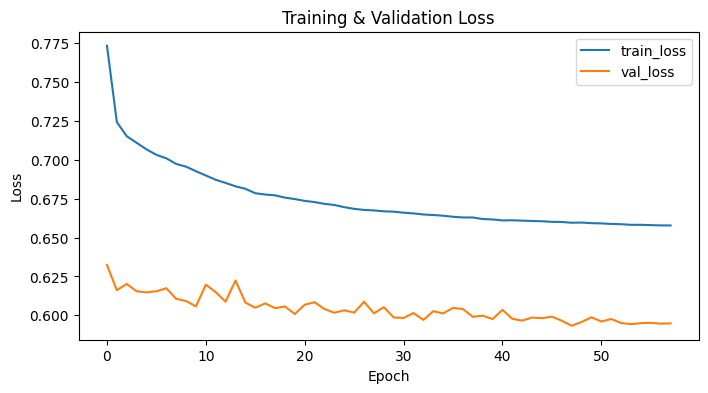

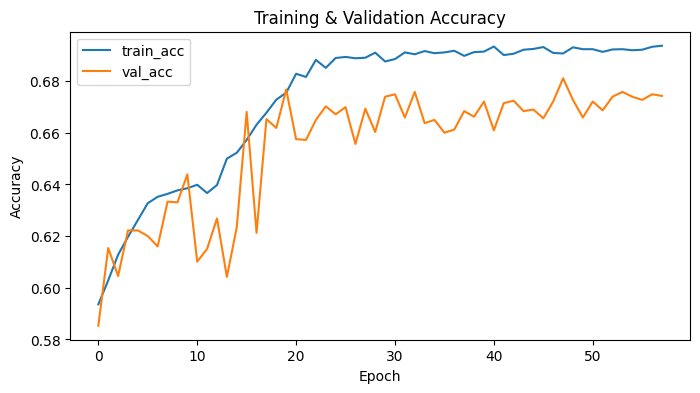

Final train_acc: 0.6938
Final val_acc:   0.6743


In [11]:
# === @title Этап 9: обучение LSTM-модели ===
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1) Определяем колбэки
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
rlrp = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)
cp_callback = ModelCheckpoint(
    filepath='checkpoints/lstm_best_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

epochs=200
batch_size=32
# рассчитываем вес редкого класса
w0 = 1.0
w1 = len(y_train[y_train==0]) / len(y_train[y_train==1])

history = model.fit(
    X_train_lstm, y_train_res,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_lstm, y_val),
    class_weight={0: w0, 1: w1},
    callbacks=[es, rlrp, cp_callback],
    verbose=2
)


# --- Отладочные графики ---

# 1) Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2) Accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'],    label='train_acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 3) Финальные метрики
print(f"Final train_acc: {history.history['accuracy'][-1]:.4f}")
print(f"Final val_acc:   {history.history['val_accuracy'][-1]:.4f}")

In [12]:
y_pred_proba = model.predict(X_test_lstm, verbose=0)
y_pred       = (y_pred_proba >= 0.5).astype(int).flatten()

# Проверим формы
print("X_test_lstm.shape =", X_test_lstm.shape)
print("y_test_lstm.shape =", y_test_lstm.shape)
print("y_pred.shape       =", y_pred.shape)

# Посчитаем метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc  = accuracy_score(y_test_lstm, y_pred)
prec = precision_score(y_test_lstm, y_pred)
rec  = recall_score(y_test_lstm, y_pred)
f1   = f1_score(y_test_lstm, y_pred)
cm   = confusion_matrix(y_test_lstm, y_pred)

print("=== Test Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")
print("=== Confusion Matrix ===")
print(cm)

X_test_lstm.shape = (3225, 1, 34)
y_test_lstm.shape = (3225,)
y_pred.shape       = (3225,)
=== Test Metrics ===
Accuracy : 0.6946
Precision: 0.5921
Recall   : 0.8673
F1-score : 0.7038

=== Confusion Matrix ===
[[1070  806]
 [ 179 1170]]


📌 Validation Metrics
Accuracy : 0.681
Precision: 0.582
Recall   : 0.846
F1       : 0.689
ROC-AUC  : 0.771

              precision    recall  f1-score   support

         0.0      0.836     0.562     0.672      1876
         1.0      0.582     0.846     0.689      1348

    accuracy                          0.681      3224
   macro avg      0.709     0.704     0.681      3224
weighted avg      0.730     0.681     0.680      3224

📌 Test Metrics
Accuracy : 0.695
Precision: 0.592
Recall   : 0.867
F1       : 0.704
ROC-AUC  : 0.790

              precision    recall  f1-score   support

         0.0      0.857     0.570     0.685      1876
         1.0      0.592     0.867     0.704      1349

    accuracy                          0.695      3225
   macro avg      0.724     0.719     0.694      3225
weighted avg      0.746     0.695     0.693      3225



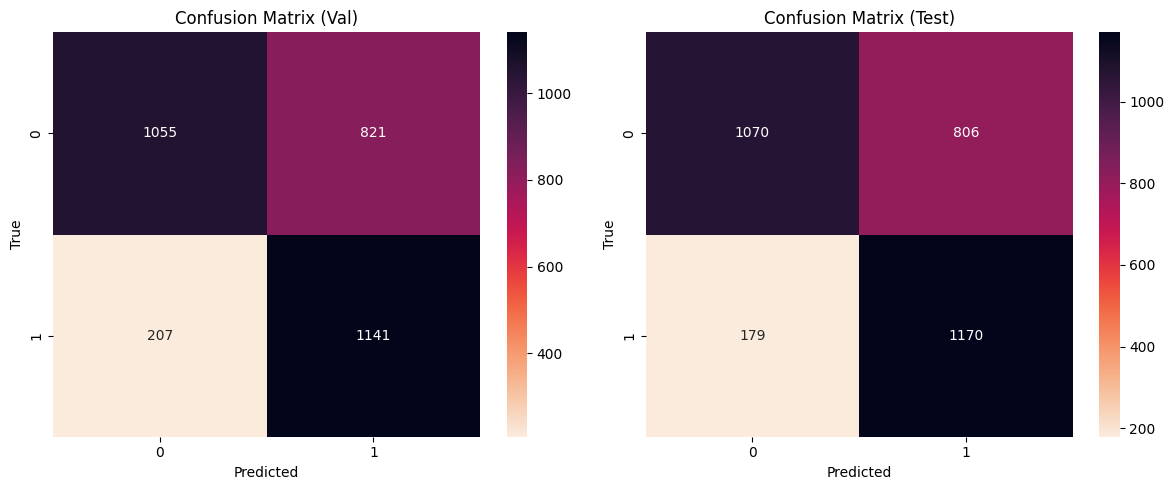

In [13]:
# %% [markdown]
# ## 📊 Метрики и confusion matrix — Val и Test

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# === Валидация ===
y_val_pred_proba = model.predict(X_val_lstm, verbose=0)
y_val_pred       = (y_val_pred_proba >= 0.5).astype(int).flatten()

# === Тест ===
y_test_pred_proba = model.predict(X_test_lstm, verbose=0)
y_test_pred       = (y_test_pred_proba >= 0.5).astype(int).flatten()

# === Метрики ===
def evaluate(y_true, y_pred, y_proba, title=""):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_proba)
    print(f"📌 {title} Metrics")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1       : {f1:.3f}")
    print(f"ROC-AUC  : {auc:.3f}")
    print()
    print(classification_report(y_true, y_pred, digits=3))

evaluate(y_val, y_val_pred, y_val_pred_proba, title="Validation")
evaluate(y_test_lstm, y_test_pred, y_test_pred_proba, title="Test")

# === Confusion Matrices ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cm_val = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt="d", cmap="rocket_r", ax=axs[0])
axs[0].set_title("Confusion Matrix (Val)")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

cm_test = confusion_matrix(y_test_lstm, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="rocket_r", ax=axs[1])
axs[1].set_title("Confusion Matrix (Test)")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [14]:
# Шаг 1: Настройка callback для сохранения лучших весов
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
import os

# Создаём папку для чекпойнтов, если её ещё нет
os.makedirs("checkpoints", exist_ok=True)

# Путь для сохранения лучших весов
checkpoint_path = "checkpoints/lstm_best_weights.h5"

# Callback для сохранения только лучших весов на основе 'val_loss'
cp_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',       # Следим за валидационной метрикой
    save_best_only=True,      # Сохраняем только лучшие веса
    mode='min',               # Минимизируем метрику (например, для val_loss)
    verbose=1,                # Печать, когда сохраняется
    save_freq='epoch'        # Сохраняем после каждой эпохи
)

# Шаг 2: Обучение модели с использованием этого колбэка
# рассчитываем вес редкого класса
w0 = 1.0
w1 = len(y_train[y_train==0]) / len(y_train[y_train==1])

history = model.fit(
    X_train_lstm, y_train_res,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_lstm, y_val),
    class_weight={0: w0, 1: w1},
    callbacks=[cp_callback],
    verbose=2
)

# Шаг 3: Сохранение модели целиком и веса
import pickle
from pathlib import Path

# 1) Создаём папку для артефактов
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

# 2) Сохраняем модель целиком (архитектура + веса)
model_path = artifacts_dir / "lstm_eth_fraud_model.h5"
model.save(str(model_path))
print(f"Модель сохранена в {model_path}")

# 3) Сохраняем scaler
scaler_path = artifacts_dir / "scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler сохранён в {scaler_path}")

# 4) Сохраняем список признаков (чтобы при загрузке знать порядок столбцов)
feature_list = X.columns.tolist()  # X – до разбиения, без FLAG
features_path = artifacts_dir / "features_list.pkl"
with open(features_path, "wb") as f:
    pickle.dump(feature_list, f)
print(f"Список признаков сохранён в {features_path}")

# Шаг 4: Извлечение и сохранение эмбеддингов
_ = model.predict(X_train_lstm[:1])

# Создаём модель для получения эмбеддингов (например, из первого LSTM слоя)
embedding_model = tf.keras.Model(inputs=model.input, outputs=model.layers[0].output)

# Извлекаем эмбеддинги для тренировочных и тестовых данных
embeddings_train = embedding_model.predict(X_train_lstm)
embeddings_test = embedding_model.predict(X_test_lstm)

# Сохраняем эмбеддинги
np.save("artifacts/embeddings_train.npy", embeddings_train)
np.save("artifacts/embeddings_test.npy", embeddings_test)
print(f"Эмбеддинги сохранены в 'artifacts/embeddings_train.npy' и 'artifacts/embeddings_test.npy'")

# Шаг 5: Проверка воспроизводимости (если необходимо)
# Загружаем модель и другие артефакты
model = tf.keras.models.load_model(str(artifacts_dir / "lstm_eth_fraud_model.h5"))
with open(artifacts_dir / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(artifacts_dir / "features_list.pkl", "rb") as f:
    features_list = pickle.load(f)

# Загружаем эмбеддинги (если нужно)
embeddings_train = np.load("artifacts/embeddings_train.npy")
embeddings_test = np.load("artifacts/embeddings_test.npy")

print("Эмбеддинги и модель успешно загружены для дальнейшего использования.")


Epoch 1/200

Epoch 1: val_loss improved from inf to 0.59631, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 1ms/step - accuracy: 0.6949 - loss: 0.6594 - val_accuracy: 0.6728 - val_loss: 0.5963
Epoch 2/200

Epoch 2: val_loss improved from 0.59631 to 0.59617, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 2ms/step - accuracy: 0.6914 - loss: 0.6592 - val_accuracy: 0.6721 - val_loss: 0.5962
Epoch 3/200

Epoch 3: val_loss improved from 0.59617 to 0.59586, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 1ms/step - accuracy: 0.6915 - loss: 0.6592 - val_accuracy: 0.6725 - val_loss: 0.5959
Epoch 4/200

Epoch 4: val_loss did not improve from 0.59586
303/303 - 0s - 1ms/step - accuracy: 0.6921 - loss: 0.6592 - val_accuracy: 0.6725 - val_loss: 0.5960
Epoch 5/200

Epoch 5: val_loss did not improve from 0.59586
303/303 - 0s - 1ms/step - accuracy: 0.6918 - loss: 0.6591 - val_accuracy: 0.6725 - val_loss: 0.5966
Epoch 6/200

Epoch 6: val_loss did not improve from 0.59586
303/303 - 0s - 1ms/step - accuracy: 0.6918 - loss: 0.6590 - val_accuracy: 0.6725 - val_loss: 0.5968
Epoch 7/200

Epoch 7: val_loss did not improve from 0.59586
303/303 - 0s - 1ms/step - accuracy: 0.6917 - loss: 0.6589 - val_accuracy: 0.6725 - val_loss: 0.5961
Epoch 8/200

Epoch 8: val_loss did not improve from 0.59586
303/303 - 0s - 1ms/step - accuracy: 0.6932 - loss: 0.6589 - val_accuracy: 0.6694 - val_loss: 0.5976
Epoch 9/200

Epoch 9: val_loss improved from 0.59586 to 0.59578, saving model to checkpoints/lstm_be

303/303 - 0s - 2ms/step - accuracy: 0.6900 - loss: 0.6588 - val_accuracy: 0.6725 - val_loss: 0.5958
Epoch 10/200

Epoch 10: val_loss did not improve from 0.59578
303/303 - 0s - 1ms/step - accuracy: 0.6927 - loss: 0.6588 - val_accuracy: 0.6721 - val_loss: 0.5964
Epoch 11/200

Epoch 11: val_loss did not improve from 0.59578
303/303 - 0s - 1ms/step - accuracy: 0.6925 - loss: 0.6587 - val_accuracy: 0.6725 - val_loss: 0.5966
Epoch 12/200

Epoch 12: val_loss did not improve from 0.59578
303/303 - 0s - 1ms/step - accuracy: 0.6912 - loss: 0.6586 - val_accuracy: 0.6721 - val_loss: 0.5964
Epoch 13/200

Epoch 13: val_loss did not improve from 0.59578
303/303 - 0s - 1ms/step - accuracy: 0.6928 - loss: 0.6586 - val_accuracy: 0.6700 - val_loss: 0.5971
Epoch 14/200

Epoch 14: val_loss did not improve from 0.59578
303/303 - 0s - 1ms/step - accuracy: 0.6919 - loss: 0.6585 - val_accuracy: 0.6712 - val_loss: 0.5968
Epoch 15/200

Epoch 15: val_loss did not improve from 0.59578
303/303 - 0s - 1ms/step - ac

...

303/303 - 0s - 1ms/step - accuracy: 0.6957 - loss: 0.6504 - val_accuracy: 0.6846 - val_loss: 0.5913
Epoch 160/200

Epoch 160: val_loss did not improve from 0.59132
303/303 - 0s - 978us/step - accuracy: 0.7000 - loss: 0.6504 - val_accuracy: 0.6827 - val_loss: 0.5921
Epoch 161/200

Epoch 161: val_loss did not improve from 0.59132
303/303 - 0s - 970us/step - accuracy: 0.6994 - loss: 0.6504 - val_accuracy: 0.6833 - val_loss: 0.5917
Epoch 162/200

Epoch 162: val_loss did not improve from 0.59132
303/303 - 0s - 1ms/step - accuracy: 0.7002 - loss: 0.6504 - val_accuracy: 0.6830 - val_loss: 0.5921
Epoch 163/200

Epoch 163: val_loss did not improve from 0.59132
303/303 - 0s - 1ms/step - accuracy: 0.7004 - loss: 0.6503 - val_accuracy: 0.6833 - val_loss: 0.5917
Epoch 164/200

Epoch 164: val_loss did not improve from 0.59132
303/303 - 0s - 1ms/step - accuracy: 0.6991 - loss: 0.6502 - val_accuracy: 0.6830 - val_loss: 0.5920
Epoch 165/200

Epoch 165: val_loss did not improve from 0.59132
303/303 - 0s

303/303 - 0s - 1ms/step - accuracy: 0.7010 - loss: 0.6490 - val_accuracy: 0.6849 - val_loss: 0.5910
Epoch 189/200

Epoch 189: val_loss did not improve from 0.59103
303/303 - 0s - 1ms/step - accuracy: 0.7009 - loss: 0.6489 - val_accuracy: 0.6833 - val_loss: 0.5913
Epoch 190/200

Epoch 190: val_loss did not improve from 0.59103
303/303 - 0s - 1ms/step - accuracy: 0.7014 - loss: 0.6489 - val_accuracy: 0.6836 - val_loss: 0.5913
Epoch 191/200

Epoch 191: val_loss did not improve from 0.59103
303/303 - 0s - 1ms/step - accuracy: 0.7013 - loss: 0.6488 - val_accuracy: 0.6824 - val_loss: 0.5916
Epoch 192/200

Epoch 192: val_loss improved from 0.59103 to 0.59090, saving model to checkpoints/lstm_best_weights.h5


303/303 - 0s - 1ms/step - accuracy: 0.6995 - loss: 0.6488 - val_accuracy: 0.6852 - val_loss: 0.5909
Epoch 193/200

Epoch 193: val_loss did not improve from 0.59090
303/303 - 0s - 1ms/step - accuracy: 0.7015 - loss: 0.6488 - val_accuracy: 0.6821 - val_loss: 0.5918
Epoch 194/200

Epoch 194: val_loss did not improve from 0.59090
303/303 - 0s - 1ms/step - accuracy: 0.7009 - loss: 0.6487 - val_accuracy: 0.6833 - val_loss: 0.5915
Epoch 195/200

Epoch 195: val_loss did not improve from 0.59090
303/303 - 0s - 1ms/step - accuracy: 0.7010 - loss: 0.6487 - val_accuracy: 0.6852 - val_loss: 0.5910
Epoch 196/200

Epoch 196: val_loss did not improve from 0.59090
303/303 - 0s - 1ms/step - accuracy: 0.7024 - loss: 0.6486 - val_accuracy: 0.6839 - val_loss: 0.5913
Epoch 197/200

Epoch 197: val_loss did not improve from 0.59090
303/303 - 0s - 996us/step - accuracy: 0.7008 - loss: 0.6485 - val_accuracy: 0.6842 - val_loss: 0.5913
Epoch 198/200

Epoch 198: val_loss did not improve from 0.59090
303/303 - 0s -

Модель сохранена в artifacts/lstm_eth_fraud_model.h5
Scaler сохранён в artifacts/scaler.pkl
Список признаков сохранён в artifacts/features_list.pkl
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


AttributeError: The layer sequential has never been called and thus has no defined input.